# Gradiant Descent

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

# Load dataset
df = pd.read_csv("Dataset.csv")

# Display dataset
print(df)

    Area  Bedrooms  Price
0   1000         2     50
1   1200         2     60
2   1400         3     70
3   1600         3     80
4   1800         3     90
5   2000         4    100
6   2200         4    110
7   2400         4    120
8   2600         5    130
9   2800         5    140
10  3000         5    150
11  3200         5    160
12  3400         6    170
13  3600         6    180
14  3800         6    190
15  4000         7    200
16  4200         7    210
17  4400         7    220
18  4600         8    230
19  4800         8    240



Final Weights: [32.0740175  25.58879537]
Final Bias: 144.9937401691255

Actual Prices:
[ 50  60  70  80  90 100 110 120 130 140 150 160 170 180 190 200 210 220
 230 240]

Predicted Prices:
[ 49.8930048   55.45534486  75.10385318  80.66619324  86.22853331
 105.87704162 111.43938169 117.00172176 136.65023007 142.21257014
 147.7749102  153.33725027 172.98575858 178.54809865 184.11043872
 203.75894703 209.3212871  214.88362716 234.53213548 240.09447554]

Final Cost: 7.813722492336741


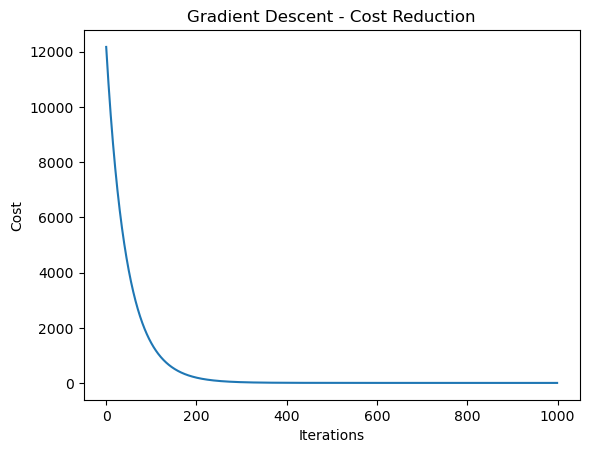

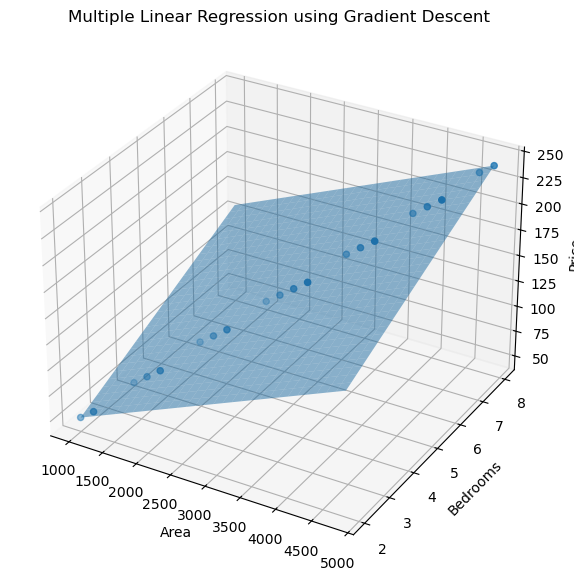

In [3]:


# Features
X = df[["Area", "Bedrooms"]].values

# Target
y = df["Price"].values

# Feature scaling
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

# Initialize parameters
w = np.zeros(X_scaled.shape[1])
b = 0

# Hyperparameters
learning_rate = 0.01
iterations = 1000

# Number of data points
m = len(y)

# Store cost
cost_history = []

# Gradient Descent
for i in range(iterations):

    # Prediction
    y_pred = np.dot(X_scaled, w) + b

    # Error
    error = y_pred - y

    # Cost
    cost = (1 / (2 * m)) * np.sum(error ** 2)

    # Gradients
    dw = (1 / m) * np.dot(X_scaled.T, error)
    db = (1 / m) * np.sum(error)

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Store cost
    cost_history.append(cost)

# Final parameters
print("\nFinal Weights:", w)
print("Final Bias:", b)

# Predictions
y_pred = np.dot(X_scaled, w) + b

print("\nActual Prices:")
print(y)

print("\nPredicted Prices:")
print(y_pred)

# Final cost
print("\nFinal Cost:", cost_history[-1])

# Plot Cost vs Iterations
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent - Cost Reduction")
plt.show()

# 3D Regression Plane
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Actual data points
ax.scatter(
    df["Area"],
    df["Bedrooms"],
    df["Price"]
)

# Create ranges for Area and Bedrooms
area_range = np.linspace(
    df["Area"].min(),
    df["Area"].max(),
    30
)

bedroom_range = np.linspace(
    df["Bedrooms"].min(),
    df["Bedrooms"].max(),
    30
)

# Create grid
area_grid, bedroom_grid = np.meshgrid(
    area_range,
    bedroom_range
)

# Scale grid using the same mean and standard deviation
area_scaled = (area_grid - X_mean[0]) / X_std[0]
bedroom_scaled = (bedroom_grid - X_mean[1]) / X_std[1]

# Predict price for every point on the grid
price_grid = (
    w[0] * area_scaled +
    w[1] * bedroom_scaled +
    b
)

# Plot regression plane
ax.plot_surface(
    area_grid,
    bedroom_grid,
    price_grid,
    alpha=0.5
)

# Labels
ax.set_xlabel("Area")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price")

ax.set_title("Multiple Linear Regression using Gradient Descent")

plt.show()